<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/descomposicion_canonicaaa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición Canónica de una Cadena de Markov


En esta notebook se analiza la matriz de transición P del problema. Primero se escribe la matriz y se dibuja su diagrama de transiciones, luego se determina si tiene distribución límite, después se obtiene la descomposición canónica junto con el límite de $P^n$, y al final se programa una función general que hace todo esto para cualquier matriz.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from fractions import Fraction


## Matriz P y diagrama de transiciones


In [2]:
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
n = len(estados)

P = np.array([
    [1/4,   0,    0,    0,    0,    0,   3/4],
    [1/8,  1/8,  1/4,   0,   1/4,  1/8,  1/8],
    [ 0,    0,   2/5,  1/5,  2/5,   0,    0 ],
    [ 0,    0,   1/2,  1/2,   0,    0,    0 ],
    [ 0,    0,    0,   1/2,  1/2,   0,    0 ],
    [ 0,   1/5,   0,   1/5,  1/5,  1/5,  1/5],
    [4/5,   0,    0,    0,    0,    0,   1/5]
])

# se verifica que cada renglón sume 1
print('Sumas por renglón:')
for i in range(n):
    print(f'  {estados[i]}: {round(sum(P[i]), 4)}')

# se imprime la matriz con fracciones para que sea más legible
print()
print('Matriz P:')
encabezado = '       ' + '  '.join(f'{s:^5}' for s in estados)
print(encabezado)
for i in range(n):
    fila = '  '.join(str(Fraction(P[i,j]).limit_denominator(10)).center(5) for j in range(n))
    print(f'  {estados[i]}  [ {fila} ]')


Sumas por renglón:
  a: 1.0
  b: 1.0
  c: 1.0
  d: 1.0
  e: 1.0
  f: 1.0
  g: 1.0

Matriz P:
         a      b      c      d      e      f      g  
  a  [  1/4     0      0      0      0      0     3/4  ]
  b  [  1/8    1/8    1/4     0     1/4    1/8    1/8  ]
  c  [   0      0     2/5    1/5    2/5     0      0   ]
  d  [   0      0     1/2    1/2     0      0      0   ]
  e  [   0      0      0     1/2    1/2     0      0   ]
  f  [   0     1/5     0     1/5    1/5    1/5    1/5  ]
  g  [  4/5     0      0      0      0      0     1/5  ]


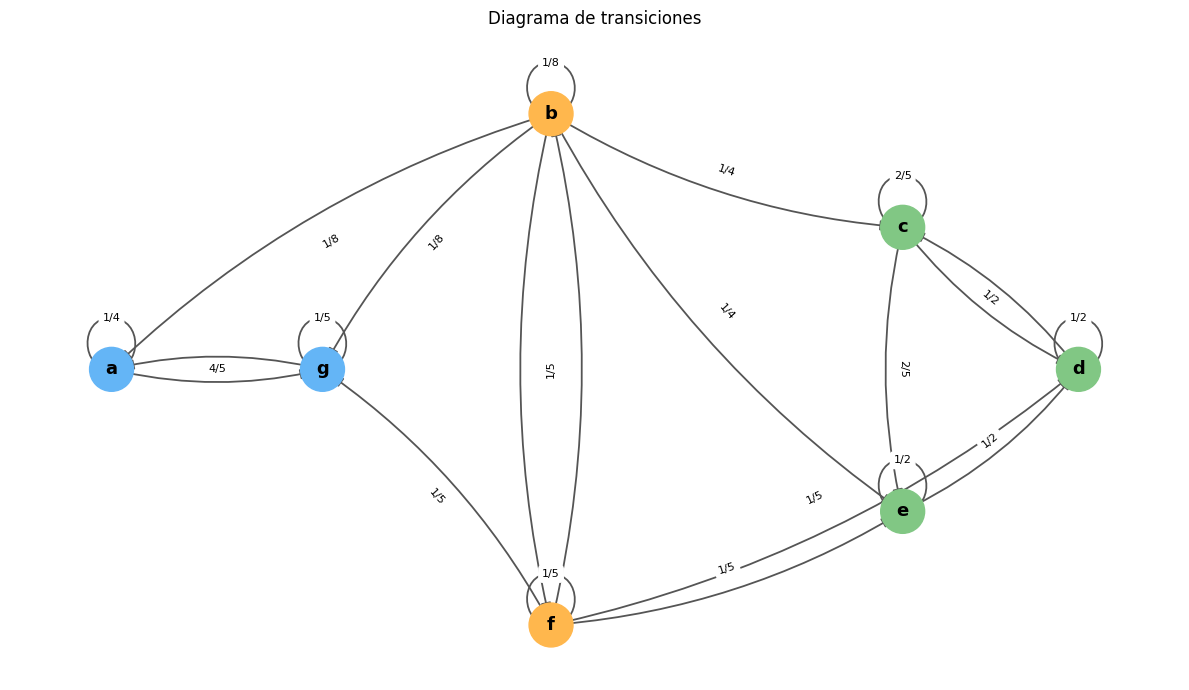

In [3]:
# se arma el grafo dirigido con las transiciones de P
G = nx.DiGraph()
G.add_nodes_from(estados)

for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G.add_edge(estados[i], estados[j])

# posiciones de los nodos — se agrupan visualmente por clase
pos = {
    'a': (-2,  0),  'g': (-0.8,  0),
    'b': ( 0.5,  1.8),  'f': ( 0.5, -1.8),
    'c': ( 2.5,  1),  'd': ( 3.5,  0),  'e': ( 2.5, -1)
}

# colores: azul = clase {a,g}, verde = clase {c,d,e}, naranja = transitorios
colores_nodo = {
    'a': '#64b5f6', 'g': '#64b5f6',
    'c': '#81c784', 'd': '#81c784', 'e': '#81c784',
    'b': '#ffb74d', 'f': '#ffb74d'
}
lista_colores = [colores_nodo[s] for s in estados]

fig, ax = plt.subplots(figsize=(12, 7))

nx.draw_networkx_nodes(G, pos, node_color=lista_colores, node_size=1000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=15,
                       edge_color='#555555', width=1.3,
                       connectionstyle='arc3,rad=0.12')

# etiquetas de probabilidades como fracciones
edge_labels = {}
for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            edge_labels[(estados[i], estados[j])] = str(Fraction(P[i,j]).limit_denominator(10))

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title('Diagrama de transiciones')
ax.axis('off')
plt.tight_layout()
plt.savefig('diagrama.png', dpi=100, bbox_inches='tight')
plt.show()


---
## ¿Tiene distribución límite?

Para que una cadena tenga distribución límite única se necesita que sea irreducible (todos los estados se comunican) y aperiódica. Se buscan las clases comunicantes para ver si eso se cumple.


In [4]:
# se arma el grafo con índices enteros para usar strongly_connected_components
G2 = nx.DiGraph()
for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G2.add_edge(i, j)

sccs = list(nx.strongly_connected_components(G2))

print('Clases comunicantes:')
for scc in sccs:
    print(' ', [estados[i] for i in sorted(scc)])

print()

# se clasifica cada clase: es recurrente si no tiene salidas hacia otras clases
clases_rec = []
transitorios = []

for scc in sccs:
    sale = False
    for i in scc:
        for j in range(n):
            if P[i, j] > 0 and j not in scc:
                sale = True
    if sale:
        transitorios.extend(sorted(scc))
        print(f'  Transitoria: {[estados[i] for i in sorted(scc)]}')
    else:
        clases_rec.append(sorted(scc))
        print(f'  Recurrente:  {[estados[i] for i in sorted(scc)]}')

print()
print('La cadena NO es irreducible — hay más de una clase recurrente.')
print('Por lo tanto, NO tiene distribución límite única.')
print()
print('Sin embargo, el límite de P^n sí existe porque todas las clases')
print('recurrentes son aperiódicas (tienen lazos en cada estado).')


Clases comunicantes:
  ['a', 'g']
  ['c', 'd', 'e']
  ['b', 'f']

  Recurrente:  ['a', 'g']
  Recurrente:  ['c', 'd', 'e']
  Transitoria: ['b', 'f']

La cadena NO es irreducible — hay más de una clase recurrente.
Por lo tanto, NO tiene distribución límite única.

Sin embargo, el límite de P^n sí existe porque todas las clases
recurrentes son aperiódicas (tienen lazos en cada estado).


---
## Descomposición canónica y límite de $P^n$

Se reordenan los estados poniendo primero las clases recurrentes y luego los transitorios. La matriz en esa forma queda como:

$$P_{\text{canon}} = \begin{pmatrix} B_1 & 0 & 0 \\ 0 & B_2 & 0 \\ R_1 & R_2 & Q \end{pmatrix}$$


In [5]:
# se arma el nuevo orden: primero recurrentes, luego transitorios
nuevo_orden = []
for c in clases_rec:
    nuevo_orden.extend(c)
nuevo_orden.extend(sorted(transitorios))

nombres_canon = [estados[i] for i in nuevo_orden]
print('Nuevo orden:', nombres_canon)

# se reordena P
P_canon = P[np.ix_(nuevo_orden, nuevo_orden)]

print()
print('Forma canónica de P:')
print('       ' + '  '.join(f'{s:^5}' for s in nombres_canon))
for i in range(n):
    fila = '  '.join(str(Fraction(P_canon[i,j]).limit_denominator(10)).center(5) for j in range(n))
    print(f'  {nombres_canon[i]}  [ {fila} ]')

# se extraen los bloques
n1 = len(clases_rec[0])
n2 = len(clases_rec[1])

B1 = P_canon[:n1, :n1]
B2 = P_canon[n1:n1+n2, n1:n1+n2]
Q  = P_canon[n1+n2:,   n1+n2:]
R1 = P_canon[n1+n2:,   :n1]
R2 = P_canon[n1+n2:,   n1:n1+n2]

print()
print('B1 =', B1)
print('B2 =', B2)
print('Q  =', Q)
print('R1 =', R1)
print('R2 =', R2)


Nuevo orden: ['a', 'g', 'c', 'd', 'e', 'b', 'f']

Forma canónica de P:
         a      g      c      d      e      b      f  
  a  [  1/4    3/4     0      0      0      0      0   ]
  g  [  4/5    1/5     0      0      0      0      0   ]
  c  [   0      0     2/5    1/5    2/5     0      0   ]
  d  [   0      0     1/2    1/2     0      0      0   ]
  e  [   0      0      0     1/2    1/2     0      0   ]
  b  [  1/8    1/8    1/4     0     1/4    1/8    1/8  ]
  f  [   0     1/5     0     1/5    1/5    1/5    1/5  ]

B1 = [[0.25 0.75]
 [0.8  0.2 ]]
B2 = [[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]
Q  = [[0.125 0.125]
 [0.2   0.2  ]]
R1 = [[0.125 0.125]
 [0.    0.2  ]]
R2 = [[0.25 0.   0.25]
 [0.   0.2  0.2 ]]


In [6]:
# distribución estacionaria de cada bloque recurrente
# se resuelve pi @ B = pi con sum(pi) = 1

def dist_estacionaria(B):
    m = len(B)
    A = B.T - np.eye(m)
    # se reemplaza el último renglón por la condición sum(pi) = 1
    A[-1, :] = 1
    b = np.zeros(m)
    b[-1] = 1
    pi = np.linalg.solve(A, b)
    return pi

nombres_B1 = [estados[i] for i in clases_rec[0]]
nombres_B2 = [estados[i] for i in clases_rec[1]]

pi1 = dist_estacionaria(B1)
pi2 = dist_estacionaria(B2)

print('Distribución estacionaria de B1', nombres_B1)
for s, p in zip(nombres_B1, pi1):
    print(f'  pi({s}) = {round(p, 6)}  aprox  {Fraction(p).limit_denominator(100)}')

print()
print('Distribución estacionaria de B2', nombres_B2)
for s, p in zip(nombres_B2, pi2):
    print(f'  pi({s}) = {round(p, 6)}  aprox  {Fraction(p).limit_denominator(100)}')


Distribución estacionaria de B1 ['a', 'g']
  pi(a) = 0.516129  aprox  16/31
  pi(g) = 0.483871  aprox  15/31

Distribución estacionaria de B2 ['c', 'd', 'e']
  pi(c) = 0.333333  aprox  1/3
  pi(d) = 0.4  aprox  2/5
  pi(e) = 0.266667  aprox  4/15


In [7]:
# se calcula el límite de P^n cuadrando la matriz repetidamente
# después de 25 iteraciones tenemos 2^25 pasos, suficiente para converger

Plim = P.copy()
for _ in range(25):
    Plim = Plim @ Plim

print('Límite de P^n:')
print('       ' + '  '.join(f'{s:^7}' for s in estados))
for i in range(n):
    fila = '  '.join(f'{Plim[i,j]:^7.4f}' for j in range(n))
    print(f'  {estados[i]}  [ {fila} ]')

print()
print('Comparación con las distribuciones estacionarias:')
print()

print(f'Renglones de {{a,g}} en P^inf vs pi1 = {np.round(pi1, 4)}')
for s in nombres_B1:
    i = estados.index(s)
    vals = [round(Plim[i, estados.index(x)], 4) for x in nombres_B1]
    print(f'  renglón {s}: {vals}')

print()
print(f'Renglones de {{c,d,e}} en P^inf vs pi2 = {np.round(pi2, 4)}')
for s in nombres_B2:
    i = estados.index(s)
    vals = [round(Plim[i, estados.index(x)], 4) for x in nombres_B2]
    print(f'  renglón {s}: {vals}')

print()
print('Para los transitorios b y f, la probabilidad de absorción en cada clase:')
for idx in sorted(transitorios):
    s = estados[idx]
    i = estados.index(s)
    p_c1 = sum(Plim[i, estados.index(x)] for x in nombres_B1)
    p_c2 = sum(Plim[i, estados.index(x)] for x in nombres_B2)
    print(f'  desde {s}: clase 1 = {round(p_c1,4)},  clase 2 = {round(p_c2,4)}')


Límite de P^n:
          a        b        c        d        e        f        g   
  a  [ 0.5161   0.0000   0.0000   0.0000   0.0000   0.0000   0.4839  ]
  b  [ 0.1720   0.0000   0.2222   0.2667   0.1778   0.0000   0.1613  ]
  c  [ 0.0000   0.0000   0.3333   0.4000   0.2667   0.0000   0.0000  ]
  d  [ 0.0000   0.0000   0.3333   0.4000   0.2667   0.0000   0.0000  ]
  e  [ 0.0000   0.0000   0.3333   0.4000   0.2667   0.0000   0.0000  ]
  f  [ 0.1720   0.0000   0.2222   0.2667   0.1778   0.0000   0.1613  ]
  g  [ 0.5161   0.0000   0.0000   0.0000   0.0000   0.0000   0.4839  ]

Comparación con las distribuciones estacionarias:

Renglones de {a,g} en P^inf vs pi1 = [0.5161 0.4839]
  renglón a: [np.float64(0.5161), np.float64(0.4839)]
  renglón g: [np.float64(0.5161), np.float64(0.4839)]

Renglones de {c,d,e} en P^inf vs pi2 = [0.3333 0.4    0.2667]
  renglón c: [np.float64(0.3333), np.float64(0.4), np.float64(0.2667)]
  renglón d: [np.float64(0.3333), np.float64(0.4), np.float64(0.2667)]
 

### Interpretación del límite

Si la cadena empieza en $a$ o $g$, se queda en $\{a,g\}$ y el renglón límite coincide con $\pi_{B_1}$. Si empieza en $c$, $d$ o $e$, lo mismo pero con $\pi_{B_2}$. Desde $b$ o $f$ la cadena termina siendo absorbida por alguna de las dos clases con las probabilidades calculadas arriba — por eso el renglón límite es una combinación de las dos distribuciones estacionarias.


---
## Programa general

Se escribe una función que recibe cualquier matriz estocástica y regresa su descomposición canónica.


In [8]:
def descomposicion_canonica(P, nombres=None):
    """
    Recibe una matriz de transición P y regresa su forma canónica.
    También regresa la clasificación de los estados.
    """
    m = len(P)
    if nombres is None:
        nombres = list(range(m))

    # se arma el grafo de la cadena
    G = nx.DiGraph()
    for i in range(m):
        for j in range(m):
            if P[i, j] > 1e-10:
                G.add_edge(i, j)

    # componentes fuertemente conexas = clases comunicantes
    sccs = list(nx.strongly_connected_components(G))

    clases_rec = []
    trans = []

    for scc in sccs:
        sale = False
        for i in scc:
            for j in range(m):
                if P[i, j] > 1e-10 and j not in scc:
                    sale = True
        if sale:
            trans.extend(sorted(scc))
        else:
            clases_rec.append(sorted(scc))

    nuevo_orden = []
    for c in clases_rec:
        nuevo_orden.extend(c)
    nuevo_orden.extend(sorted(trans))

    P_c = P[np.ix_(nuevo_orden, nuevo_orden)]
    nombres_c = [nombres[i] for i in nuevo_orden]

    return P_c, clases_rec, sorted(trans), nombres_c


# prueba con nuestra matriz
print('=== Prueba con la matriz del problema ===')
Pc, rec, tra, noms = descomposicion_canonica(P, estados)
print('Clases recurrentes  :', [[estados[i] for i in c] for c in rec])
print('Estados transitorios:', [estados[i] for i in tra])
print('Nuevo orden         :', noms)

print()

# segunda prueba con una cadena absorbente sencilla
print('=== Prueba con cadena absorbente simple ===')
P2 = np.array([
    [1.0,  0.0,  0.0,  0.0],
    [0.0,  1.0,  0.0,  0.0],
    [0.5,  0.0,  0.5,  0.0],
    [0.0,  0.5,  0.25, 0.25]
])
nombres2 = ['abs0', 'abs1', 'trans2', 'trans3']
Pc2, rec2, tra2, noms2 = descomposicion_canonica(P2, nombres2)
print('Clases recurrentes  :', [[nombres2[i] for i in c] for c in rec2])
print('Estados transitorios:', [nombres2[i] for i in tra2])
print('Nuevo orden         :', noms2)
print()
print('Forma canónica:')
print(np.round(Pc2, 3))


=== Prueba con la matriz del problema ===
Clases recurrentes  : [['a', 'g'], ['c', 'd', 'e']]
Estados transitorios: ['b', 'f']
Nuevo orden         : ['a', 'g', 'c', 'd', 'e', 'b', 'f']

=== Prueba con cadena absorbente simple ===
Clases recurrentes  : [['abs0'], ['abs1']]
Estados transitorios: ['trans2', 'trans3']
Nuevo orden         : ['abs0', 'abs1', 'trans2', 'trans3']

Forma canónica:
[[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.5  0.   0.5  0.  ]
 [0.   0.5  0.25 0.25]]
